# Simulazione d'esame Laboratorio di Programmazione 2

## Esercizio 1

1. Crea un vettore NumPy con i seguenti **canoni mensili d'affitto** (in euro) per 4 appartamenti: **720, 980, 650, 1200**

2. Calcola la **spesa totale mensile** sostenuta dagli inquilini.

3. Il proprietario dell'appartamento da **1200 €** decide di **aumentare l’affitto del 12%**.
    - Modifica il vettore per applicare l’aumento.
    - L’importo aggiornato deve essere esattamente **1344,00 €**, controlla se appare **esattamente** nel tuo array.


4. L'inquilino dell'appartamento da **650 €** ottiene uno **sconto del 10%**.
    - Applica la modifica.

5. Gli altri due appartamenti (**720 € e 980 €**) subiscono un **aumento del 5%**.
    - Aggiorna il vettore di conseguenza.

7. Calcola la **nuova spesa totale mensile** dopo tutti i cambiamenti.

8. Infine: quanto ha influito **l’aumento dell’affitto più alto** sulla spesa complessiva?

    (Suggerimento: confronta la spesa totale **prima di qualsiasi modifica** e **dopo il solo aumento del canone a 1200 €**.)


In [ ]:
import numpy as np

#1.
affitto = np.array([720, 980, 650, 1200])

#2.
somma_i = sum(affitto)

#3.
affitto[affitto == 1200] = 1200+1200*(12/100)
somma_c = sum(affitto)

#4.
affitto[affitto == 650] = 650 - 650*(10/100)

#5.
affitto[affitto == 720] = 720 + 720*(5/100)
affitto[affitto == 980] = 980 + 980*(5/100)

#6.
somma_f = sum(affitto)

#7.
somma_c  - somma_i
#ha influito di 144€

np.int64(144)

## Esercizio 2

Consideriamo un semplice processo di random walk (cammino aleatorio) in una dimensione:
a ogni passo temporale, un camminatore si sposta a destra (+1) o a sinistra (-1) con uguale probabilità. Supponiamo che il camminatore parta sempre da x=0.

1. Scrivi una funzione che simula il cammino per n passi ed N camminatori e restituisce due array. Il primo rappresenta la media della posizione ad ogni passo degli N camminatori ed il secondo la deviazione standard della posizione ad ogni passo degli N camminatori.

2. Fai prima il plot della media delle posizione degli N camminatori per 100 passi 

3. Fai il plot con anche la devizione standard.  La deviazione standard diminuisce all'aumentare del campione? Che andamento ha la deviazione standard rispeto l tempo/passi?

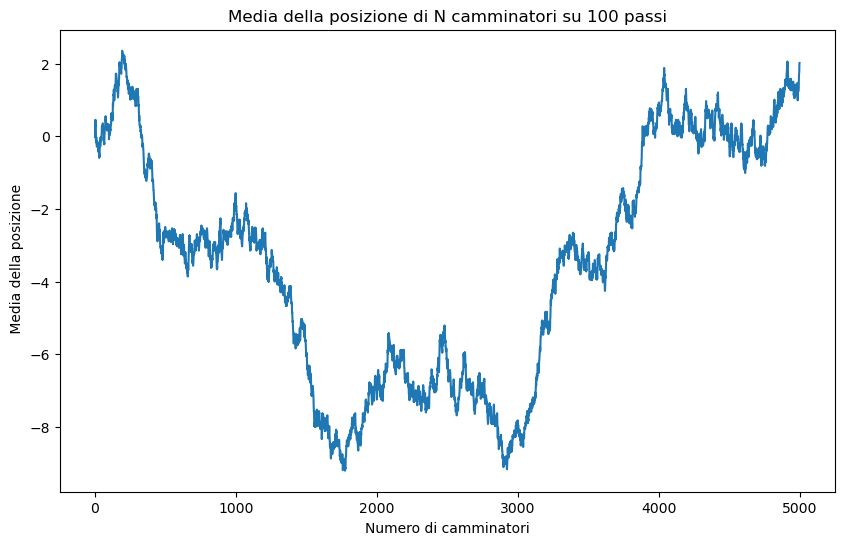

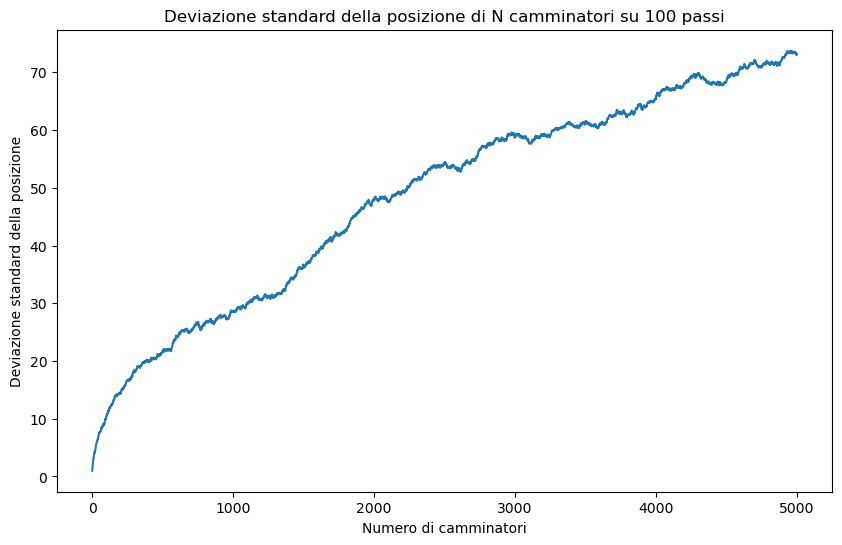

In [ ]:
import matplotlib.pyplot as plt

x = 0

#1.
def Random_Walk(n, N):

    x = np.zeros((n+1, N))  #inserisce un numero di zeri pari a quanto richiesto

    np.random.seed(42)  #setto il seed così non cambiano i dati nel tempo
    steps = np.random.choice([-1, 1], size = (n, N))    #randomizzo il passo

    x[1:, :] = np.cumsum(steps, axis = 1)   #sommo i passi randomici: somma cumulativa su una matrice

    positions_mean = x.mean(axis = 0)   #calcolo il vettore media
    standard_deviation = x.std(axis = 0)    #calcolo il vettore con le deviazioni standard

    return positions_mean, standard_deviation

#2.
media, dev_std = Random_Walk(100, 5000)

plt.figure(figsize = (10, 6))
plt.plot(media)
plt.xlabel("Numero di camminatori")
plt.ylabel(" Media della posizione")
plt.title("Media della posizione di N camminatori su 100 passi")
plt.show()

#3.
plt.figure(figsize= (10, 6))
plt.plot(dev_std)
plt.xlabel("Numero di camminatori")
plt.ylabel("Deviazione standard della posizione")
plt.title("Deviazione standard della posizione di N camminatori su 100 passi")
plt.show()

Risposta: Si può notare come a ogni randomizzazione dei passi, media cambi drasticamente, mentre la deviazione standard rimane pressochè crescente.

## Esercizio 3

Genera un array `a` di dimensioni **5 x 9** contenente numeri da una distribuzione gaussiana con media 0 e dev standard 1.  
Per ogni riga, seleziona il numero **più vicino a 0.1**.
Imposta il seed per la riproducibilità `np.random.seed(42)`

 *Suggerimento*: per ottenere `a[i, j]`, l'array `i` deve contenere gli **indici di riga** corrispondenti agli elementi in `j`.


In [ ]:
np.random.seed(42)
#mia versione
# a = np.random.standard_normal([5,9])
# print(a)

# for i, lista in enumerate(a):
#     minore = lista[0]
#     for j, item in enumerate(lista):
#         if abs(item-0.1) < abs(minore-0.1):
#             minore = item
#     print(minore)

#con numpy
a = np.random.rand(5, 9)    #randomizza dei valori tra 0 e 1(segue una distribuzione normale standard)
distanze = np.abs(a - 0.1)  #calcola il valore assoluto di ogni elemento dell'array
j = np.argmin(distanze, axis = 1)   #prende l'argomento minore tra le distanze calcolate
i = np.arange(a.shape[0])   #a.shape ha in se il numero di righe e colonne
vicini = a[i, j]
vicini


[[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337 -0.23413696
   1.57921282  0.76743473 -0.46947439]
 [ 0.54256004 -0.46341769 -0.46572975  0.24196227 -1.91328024 -1.72491783
  -0.56228753 -1.01283112  0.31424733]
 [-0.90802408 -1.4123037   1.46564877 -0.2257763   0.0675282  -1.42474819
  -0.54438272  0.11092259 -1.15099358]
 [ 0.37569802 -0.60063869 -0.29169375 -0.60170661  1.85227818 -0.01349722
  -1.05771093  0.82254491 -1.22084365]
 [ 0.2088636  -1.95967012 -1.32818605  0.19686124  0.73846658  0.17136828
  -0.11564828 -0.3011037  -1.47852199]]


array([0.07455064, 0.11586906, 0.06355835, 0.11959425, 0.10789143])

## Esercizio 4

Utilizza il dataset `titanic`, disponibile all'url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

Esegui un’analisi esplorativa sui dati dei passeggeri, focalizzandoti su tariffe, età e componenti familiari.

1. **Visualizza i primi 10 passeggeri ordinati per tariffa pagata** (`Fare`), dal più alto al più basso.

2. **Calcola la media** di:
   - `Age` (età)
   - `Fare` (tariffa)
   - `SibSp` (numero di fratelli/coniugi a bordo)

3. **Crea una nuova colonna** chiamata `Family_index`, definita come:

   $$
   \texttt{family\_index} = \frac{\texttt{sibsp} + \texttt{parch}}{\texttt{fare}}
   $$

   *(Indicatore del “peso familiare” per unità di spesa – attenzione a eventuali divisioni per zero!)*

4. Trova il **passeggero con il valore massimo** di `Family_index`.

5. **Filtra solo i passeggeri** che hanno pagato **più di 100** di tariffa (`Fare > 100`).

6. **Crea un grafico a barre** con i 10 passeggeri che hanno pagato di più (`Fare`).

7. **Crea un grafico a linee** dell’età (`Age`), ordinando i passeggeri per tariffa (`Fare`) crescente.



💡 *Suggerimenti*:
- Ricordati di gestire eventuali valori mancanti in `Age` o `Fare` prima di fare operazioni.


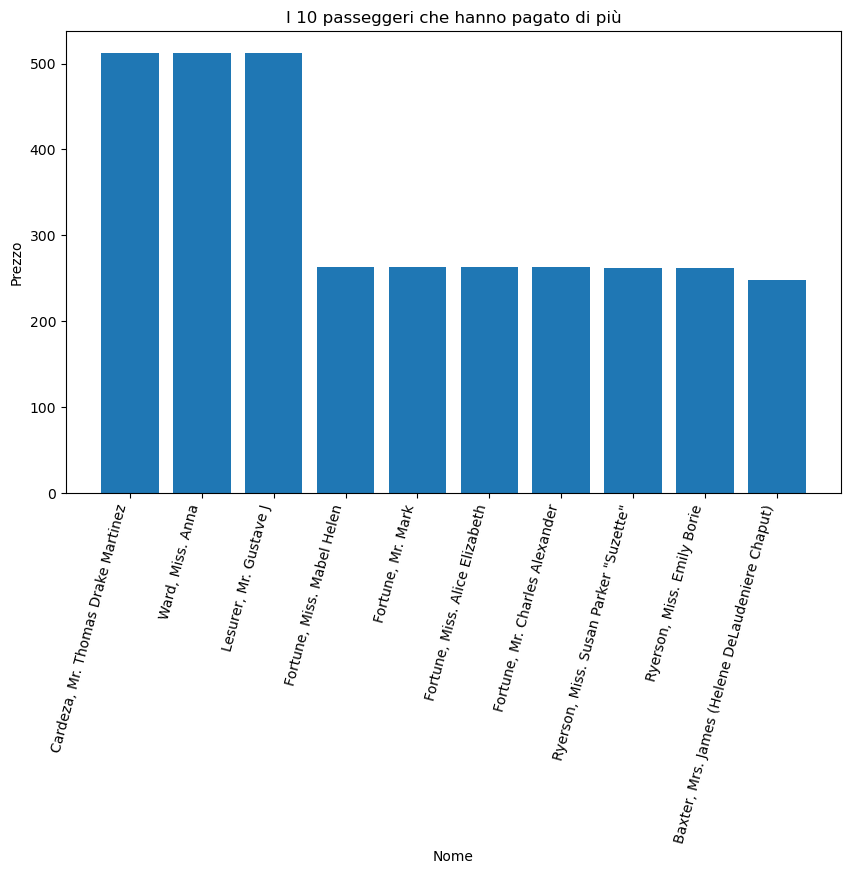

In [70]:
import pandas as pd

titanic = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
titanic

#1.
top10 = titanic.sort_values(by = "Fare", ascending = False).head(10) #ordino i valori in maniera decrescente e poi prendo i primi 10

#2.
titanic["Age"].mean()
titanic["Fare"].mean()
titanic["SibSp"].mean()

#3.
titanic["Family_index"] = (titanic["SibSp"]+titanic["Parch"])/titanic["Fare"]
titanic

#4.
titanic["Family_index"].max()

#5.
titanic[titanic["Fare"] > 100]

#6.

plt.figure(figsize=(10, 6))
plt.bar(top10["Name"], top10["Fare"])
plt.xticks(rotation = 75, ha = "right")
plt.title("I 10 passeggeri che hanno pagato di più")
plt.xlabel("Nome")
plt.ylabel("Prezzo")
plt.show()

## Esercizio 5

Usa il dataset `penguins`, disponibile tramite `seaborn.load_dataset("penguins")`.


1. Quante righe e colonne ha il dataset?

2. Controlla quanti valori mancanti ci sono per colonna.

3. Riempi i valori mancanti nella colonna `sex` con il valore più frequente.

4. Rimuovi le righe in cui il valore `body_mass_g` è mancante.

5. Controlla se ci sono righe duplicate.

6. Calcola la **massa corporea media** (`body_mass_g`) per ogni specie (`species`).
  Se ci sono valori mancanti in `body_mass_g`, riempili con la media della specie.

7. Visualizza la **distribuzione della massa corporea** (`body_mass_g`) per specie.

8.  Visualizza la **distribuzione della massa corporea** per specie, **dividendo per sesso** (`sex`) e mostrandoli a confronto.


💡 Suggerimento: usa `seaborn.violinplot()`, `boxplot()` o `kdeplot()` con `hue='sex'`.


C:\Users\orest\AppData\Local\Temp\ipykernel_25528\3341973065.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = penguins, x = "species", y = "body_mass_g", palette="Set1")


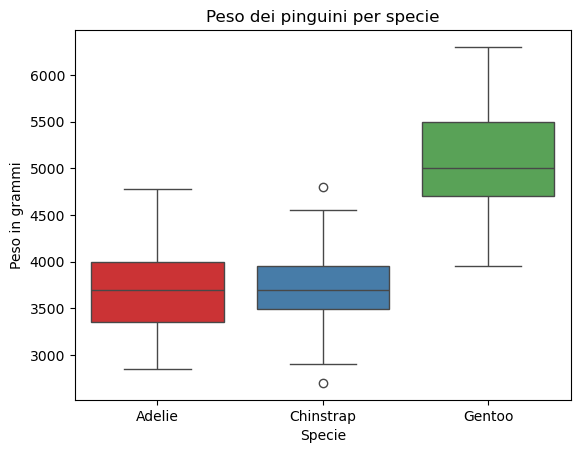

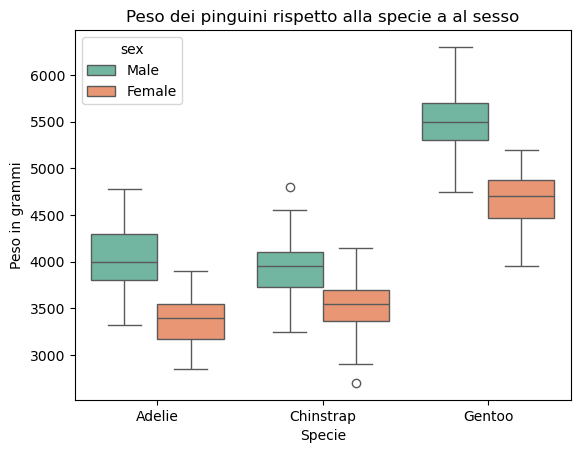

In [111]:
import seaborn as sns

penguins = sns.load_dataset("penguins")

#1.
penguins.shape
penguins

#2.
penguins.isna().sum()   #assegna a tutti gli NA 1 e agli altri 0 e poi li somma per colonna

#3.
penguins["sex"].fillna(penguins["sex"].mode()[0])   #fillna: sostituisce gli NA, mode: calcola la moda, l'indice 0 è perchè consideriamo la prima riga della moda

#4.
penguins = penguins.dropna(subset = "body_mass_g")  #tolgo le righe con NA in body_mass_g

#5.
penguins.duplicated().sum() #non ci sono duplicati

#6.
mass_mean = penguins["body_mass_g"].mean()
penguins["body_mass_g"].fillna(mass_mean)

#7.
sns.boxplot(data = penguins, x = "species", y = "body_mass_g", palette="Set1")
plt.title("Peso dei pinguini per specie")
plt.xlabel("Specie")
plt.ylabel("Peso in grammi")
plt.show()

#8.
sns.boxplot(data = penguins, x = "species", y = "body_mass_g", hue = "sex", palette = "Set2")
plt.title("Peso dei pinguini rispetto alla specie a al sesso")
plt.ylabel("Peso in grammi")
plt.xlabel("Specie")
plt.show()


## Esercizio 6

Hai due array NumPy generati come segue:

`x = np.linspace(0, 10, 100)`  
`y = 3 * x + 2 + np.random.normal(0, 1, 100)`

Scrivi una funzione `fit_line(x, y)` che:

- usa `scipy.optimize.curve_fit` per eseguire un **fitting lineare** del tipo `y = a * x + b`;  
- restituisce una tupla contenente:
  - i **parametri ottimizzati** `a` e `b`;  
  - una **stringa** che descrive la retta trovata, ad esempio: `"y = 3.02 * x + 1.95"`.


Esempio di output atteso:   (3.02, 1.95, "y = 3.02 * x + 1.95")

Fai un esempio di utilizzo dove poi plotti i dati e la curva ottenuta.


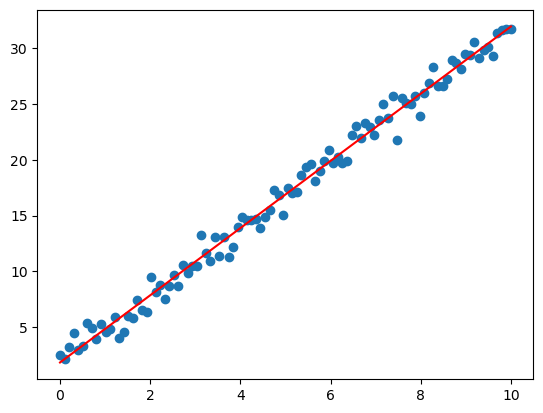

In [ ]:
import scipy as sp

np.random.seed(42)
x = np.linspace(0, 10, 100)
y = 3*x + 2+ np.random.normal(0, 1, 100)

def retta(x, a, b):
    return a*x + b

def fit_line(x, y):

    curva, _ = sp.optimize.curve_fit(retta, x, y)

    a, b = curva

    return (a, b, f"y= {a} * x + {b}\n")

a, b, eq = fit_line(x, y)

plt.scatter(x, y)
plt.plot(x, retta(x, a, b), color = "red")  #curva ottenuta
plt.show()